# Astrometry models

Looking into the astrometric models provided by David and seeing how best to use them


## Imports


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from gaianir_open_clusters.gaia_nir_config import ASTROMETRIC_DATA
from gaianir_open_clusters.astrometry import AstrometryModel
from gaianir_open_clusters.photometry import PHOTOMETRY_PREDICTOR, FILTERS
from ocelot.simulate.photometry import load_isochrone
from astropy import constants
from scipy.interpolate import interp1d

## Reproducing plots in the Hobbs+ paper


In [2]:
gaia_dr5 = AstrometryModel(years=10, mission="Gaia")
gaia_nir_l = AstrometryModel(years=10, mission="GaiaNIR-L")

In [6]:
def combined_astrometry(stars, model_1, model_2, separation=20, max_magnitude=None):
    pmra_error_1, pmdec_error_1, _ = model_1.predict(stars)
    pmra_error_2, pmdec_error_2, parallax_error = model_2.predict(stars)

    separation = model_1.years / 2 + model_2.years / 2 + separation

    pmra_error_combined = (pmra_error_1**-2 + pmra_error_2**-2) ** -0.5 / separation
    pmdec_error_combined = (pmdec_error_1**-2 + pmdec_error_2**-2) ** -0.5 / separation

    if max_magnitude is not None:
        do_not_combine = stars['G'] > max_magnitude
        pmra_error_combined[do_not_combine] = pmra_error_2[do_not_combine]
        pmdec_error_combined[do_not_combine] = pmdec_error_2[do_not_combine]

    return (
        pmra_error_2,
        pmdec_error_2,
        parallax_error,
        pmra_error_combined,
        pmdec_error_combined,
    )

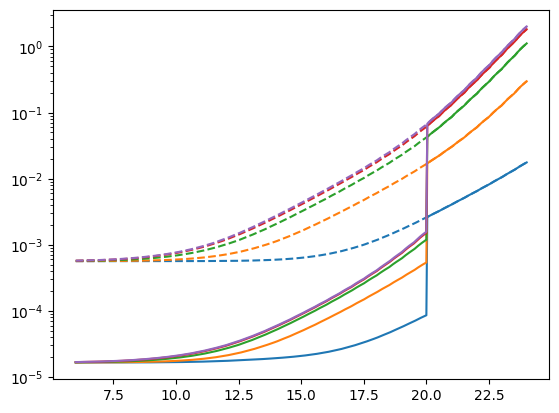

In [15]:
fig, ax = plt.subplots()

cmap = plt.get_cmap("tab10")

for i, teff in enumerate(np.geomspace(2000, 50000, num=5)):
    stars = pd.DataFrame.from_dict(
        dict(teff=teff, label=0, G=np.linspace(6, 24, num=500))
    )
    (
        pmra_error,
        pmdec_error,
        parallax_error,
        pmra_error_combined,
        pmdec_error_combined,
    ) = combined_astrometry(stars, gaia_dr5, gaia_nir_l, max_magnitude=20)
    # pmra_error, pmdec_error, parallax_error = gaia_nir_l.predict(stars)

    color = cmap(i)
    ax.plot(stars["G"], pmra_error, '--', color=color)
    ax.plot(stars["G"], pmra_error_combined, color=color)
    ax.set(yscale="log")

## Thinking about fair extension methods

In [133]:
class Params:
    log_age = np.log10(1e7)
    metallicity = 0.0


class Dummy:
    parameters = Params()


iso = load_isochrone(Dummy())
iso["temperature"] = 10 ** iso["logTe"]
iso["luminosity"] = 10 ** iso["logL"] * constants.L_sun.value

# _ = gaia_nir_phot.predict(iso)

predictions = PHOTOMETRY_PREDICTOR.predict(iso)


In [134]:
iso_good = iso.loc[iso['label'] < 2]

g_int = interp1d(iso_good['temperature'], iso_good['Gmag'])
n_int = interp1d(iso_good['temperature'], iso_good['N'])

g_to_n_int = interp1d(iso_good['Gmag'], iso_good['N'])

In [135]:
temp = 3800
distance = 13440

d_factor = 5 * np.log10(distance) - 5
print(g_int(3800) + d_factor)
print(n_int(3800) + d_factor)

8.849499100616562
6.394604891603473


In [136]:
def mag_to_electrons(mag):
    calibration_factor = 427.54392151861185 / 10.738344786983658

    return 10 ** ((mag - FILTERS["N"].Vega_zero_mag) / -2.5) * calibration_factor

In [137]:
mag_to_electrons(21.697257749094998)

np.float64(427.54392151861185)

In [153]:
temp = 25600
distance = 623.6

d_factor = 5 * np.log10(distance) - 5
print(g_int(temp) + d_factor)
# print()

6.000264930911065


In [156]:
mag_to_electrons(n_int(temp) + d_factor)

np.float64(474372467.396921)

In [28]:
predictions = PHOTOMETRY_PREDICTOR.predict(iso)

predictions[['temperature', 'Gmag', 'N']]

,temperature,Gmag,N
0,2307.809730,15.376,11.347790
1,2450.755579,14.916,10.875481
2,2618.183008,14.349,10.335450
3,2657.663550,14.147,10.219619
4,2782.274658,13.422,9.776406
...,...,...,...
365,4474.041416,-0.320,-2.058232
366,4446.312675,-0.391,-2.150319
367,4421.809211,-0.454,-2.231430
368,4397.440784,-0.514,-2.312622
